<a href="https://colab.research.google.com/github/EnricoCeci/Machine-Learning-Projects/blob/main/Random_forest_credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Credit Scoring Model

The Decision Tree and Random Forest are the model selected for this project.

The Decision Tree because of its interpretability, thanks to its if–then rules and the possibility of reconstructing a decision path for each individual customer.

The Random Forest will serve as the reference predictive model, as it is more robust than a single tree and generally more accurate.

In [ ]:
# IMPORT MODULES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score
from sklearn.tree import export_graphviz
from IPython.display import Image, display
import graphviz

pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
# MOUNT DRIVE

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT DATASET

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/7 - ML: Modelli e Algoritmi/Progetto Finale/credit_scoring (1).csv")

df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,"424,380.57",Working,Higher education,Civil marriage,Rented apartment,"-11,778.00","-4,438.00",1.00,1.00,0.00,0.00,NaN,2.00,0
1,5008805,M,Y,Y,0,"421,593.52",Working,Higher education,Civil marriage,Rented apartment,"-11,777.00","-4,459.00",1.00,1.00,0.00,0.00,NaN,2.00,0
2,5008806,M,Y,Y,0,"110,958.51",Working,Secondary / secondary special,Married,House / apartment,"-21,471.00","-1,144.00",1.00,0.00,0.00,0.00,Security staff,2.00,0
3,5008808,F,N,Y,0,"267,497.96",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-18,489.00","-3,122.00",1.00,0.00,1.00,1.00,Sales staff,1.00,1
4,5008809,F,N,Y,0,"263,419.09",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-19,093.00","-3,070.00",1.00,0.00,1.00,1.00,Sales staff,1.00,1


In [ ]:
# CHECK VARIABLE TYPES AND THE NUMBER OF NON-NULL VALUES FOR EACH COLUMN

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

In [ ]:
# COUNT CUSTOMERS WITH HIGH CREDITWORTHINESS AND THOSE WITHOUT IT

"""
Analysis of the distribution of the "TARGET" variable to identify any imbalance
between customers considered reliable and those considered not reliable.
"""

counts = df["TARGET"].value_counts()
counts

,count
TARGET,
0,308705
1,29722


A clear imbalance emerges. The number of customers considered not reliable (91.2% of the total observations) is more than ten times higher than the number of customers considered reliable (8.8%).

##Data Cleaning

The general information about the dataset suggests the possible presence of one row affected by data-recording issues. In fact, no "NaN" values are present up to the seventh variable, while each of the following variables contains exactly one "NaN" value, with the exception of OCCUPATION_TYPE, where the high number of "NaN" values cannot be due to data-recording errors but must instead reflect a structural lack of information or a specific recording choice.

It is more likely that there is a single defective observation than 10 defective observations, each with a missing value for a different variable.

In [ ]:
# CHECK THE DISTRIBUTION OF NaN VALUES BY ROW

df.isna().sum(axis=1).value_counts()

,count
0,235085
1,103341
10,1


The hypothesis of a "defective" row is confirmed. I will now identify it.

In [ ]:
# IDENTIFY THE ROW WITH 10 "NaN" VALUES

row_10_nan = df[df.isna().sum(axis=1) == 10]
row_10_nan

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
338426,6392180,F,N,N,0,"68,765.48",Working,Secondary / se,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


I create a copy of the original dataset to perform the cleaning operations.

In [ ]:
df_copy = df.copy()

df_copy.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,"424,380.57",Working,Higher education,Civil marriage,Rented apartment,"-11,778.00","-4,438.00",1.00,1.00,0.00,0.00,NaN,2.00,0
1,5008805,M,Y,Y,0,"421,593.52",Working,Higher education,Civil marriage,Rented apartment,"-11,777.00","-4,459.00",1.00,1.00,0.00,0.00,NaN,2.00,0
2,5008806,M,Y,Y,0,"110,958.51",Working,Secondary / secondary special,Married,House / apartment,"-21,471.00","-1,144.00",1.00,0.00,0.00,0.00,Security staff,2.00,0
3,5008808,F,N,Y,0,"267,497.96",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-18,489.00","-3,122.00",1.00,0.00,1.00,1.00,Sales staff,1.00,1
4,5008809,F,N,Y,0,"263,419.09",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-19,093.00","-3,070.00",1.00,0.00,1.00,1.00,Sales staff,1.00,1


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

In [ ]:
# REMOVE THE ROW WITH 10 "NaN" VALUES

df_copy = df_copy.drop(row_10_nan.index)


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338426 non-null  int64  
 1   CODE_GENDER          338426 non-null  object 
 2   FLAG_OWN_CAR         338426 non-null  object 
 3   FLAG_OWN_REALTY      338426 non-null  object 
 4   CNT_CHILDREN         338426 non-null  int64  
 5   AMT_INCOME_TOTAL     338426 non-null  float64
 6   NAME_INCOME_TYPE     338426 non-null  object 
 7   NAME_EDUCATION_TYPE  338426 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

In [ ]:
# CAST INTEGER VARIABLES STORED AS FLOATS

"""
Casting will be applied to the variables:
FLAG_MOBIL
FLAG_WORK_PHONE
FLAG_PHONE
FLAG_EMAIL
because they are binary variables stored inappropriately as floats.
The same operation will be applied to the variable:
CNT_FAM_MEMBERS
because it consists of integer values stored as floats.
"""

float_to_int = ["FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "CNT_FAM_MEMBERS"]

df_copy[float_to_int] = df_copy[float_to_int].astype(int)

df_copy.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,"424,380.57",Working,Higher education,Civil marriage,Rented apartment,"-11,778.00","-4,438.00",1,1,0,0,NaN,2,0
1,5008805,M,Y,Y,0,"421,593.52",Working,Higher education,Civil marriage,Rented apartment,"-11,777.00","-4,459.00",1,1,0,0,NaN,2,0
2,5008806,M,Y,Y,0,"110,958.51",Working,Secondary / secondary special,Married,House / apartment,"-21,471.00","-1,144.00",1,0,0,0,Security staff,2,0
3,5008808,F,N,Y,0,"267,497.96",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-18,489.00","-3,122.00",1,0,1,1,Sales staff,1,1
4,5008809,F,N,Y,0,"263,419.09",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-19,093.00","-3,070.00",1,0,1,1,Sales staff,1,1


In [ ]:
# LABEL ENCODING OF THE "FLAG_OWN_CAR" AND "FLAG_OWN_REALTY" VARIABLES

car_realty_mapping = {"N": 0, "Y": 1}

df_copy[["FLAG_OWN_CAR", "FLAG_OWN_REALTY"]] = (
    df_copy[["FLAG_OWN_CAR", "FLAG_OWN_REALTY"]].replace(car_realty_mapping))

df_copy.head()

/tmp/ipython-input-159893944.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[["FLAG_OWN_CAR", "FLAG_OWN_REALTY"]].replace(car_realty_mapping))


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,1,1,0,"424,380.57",Working,Higher education,Civil marriage,Rented apartment,"-11,778.00","-4,438.00",1,1,0,0,NaN,2,0
1,5008805,M,1,1,0,"421,593.52",Working,Higher education,Civil marriage,Rented apartment,"-11,777.00","-4,459.00",1,1,0,0,NaN,2,0
2,5008806,M,1,1,0,"110,958.51",Working,Secondary / secondary special,Married,House / apartment,"-21,471.00","-1,144.00",1,0,0,0,Security staff,2,0
3,5008808,F,0,1,0,"267,497.96",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-18,489.00","-3,122.00",1,0,1,1,Sales staff,1,1
4,5008809,F,0,1,0,"263,419.09",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-19,093.00","-3,070.00",1,0,1,1,Sales staff,1,1


I used `.replace` instead of `.map` because, `.map` converted everything to `NaN` due to values not being recorded exactly as "Y" and "N".

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338426 non-null  int64  
 1   CODE_GENDER          338426 non-null  object 
 2   FLAG_OWN_CAR         338426 non-null  int64  
 3   FLAG_OWN_REALTY      338426 non-null  int64  
 4   CNT_CHILDREN         338426 non-null  int64  
 5   AMT_INCOME_TOTAL     338426 non-null  float64
 6   NAME_INCOME_TYPE     338426 non-null  object 
 7   NAME_EDUCATION_TYPE  338426 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  int64  
 13  FLAG_WORK_PHONE      338426 non-null  int64  
 14  FLAG_PHONE           338426 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
# REPLACE "NaN" WITH "UNKNOWN"

df_copy["OCCUPATION_TYPE"] = df_copy["OCCUPATION_TYPE"].fillna("Unknown")
df_copy.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,1,1,0,"424,380.57",Working,Higher education,Civil marriage,Rented apartment,"-11,778.00","-4,438.00",1,1,0,0,Unknown,2,0
1,5008805,M,1,1,0,"421,593.52",Working,Higher education,Civil marriage,Rented apartment,"-11,777.00","-4,459.00",1,1,0,0,Unknown,2,0
2,5008806,M,1,1,0,"110,958.51",Working,Secondary / secondary special,Married,House / apartment,"-21,471.00","-1,144.00",1,0,0,0,Security staff,2,0
3,5008808,F,0,1,0,"267,497.96",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-18,489.00","-3,122.00",1,0,1,1,Sales staff,1,1
4,5008809,F,0,1,0,"263,419.09",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-19,093.00","-3,070.00",1,0,1,1,Sales staff,1,1


#Bivariate EDA

Not all variables will be considered in the exploratory analysis. The primary focus will be on those closely related to the subject's income situation.

Since creditworthiness is reflected in the consistent payment of instalments, the indicators to consider are necessarily those related to the source and amount of income, because instalments are repaid on time through income flows (payments could also be made using income from investments or other sources, but this dataset does not contain a variable capturing the presence of investments or other forms of passive income).

Other variables worth considering are socio-demographic ones, such as the number of children (more children correspond to more sources of expenditure that could undermine payment punctuality) and the presence of a spouse or partner (that is, another person who, if they have an income stream, could financially support the indebted individual).

Contingency tables were chosen to explore the relationship between the target and qualitative variables, while boxplots were used to analyse the relationship between the target and quantitative variables.

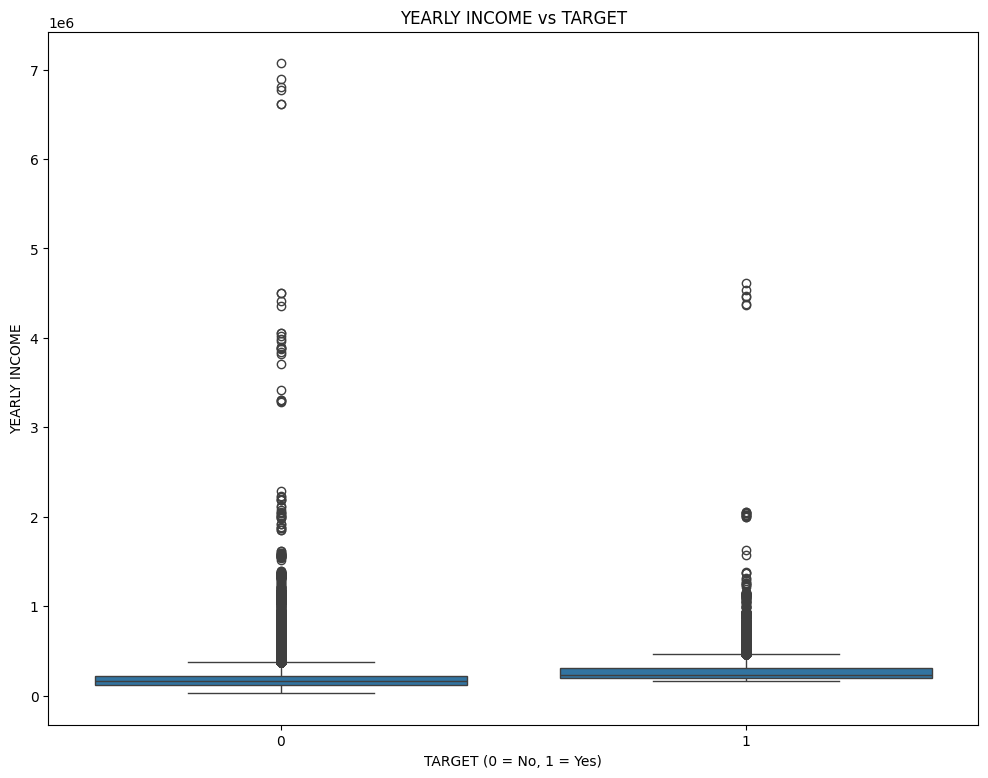

In [ ]:
# RELATIONSHIP BETWEEN "AMT_INCOME_TOTAL" AND "TARGET"

plt.figure(figsize=(12, 9))

sns.boxplot(
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    data=df_copy
)

plt.xlabel("TARGET (0 = No, 1 = Yes)")
plt.ylabel("YEARLY INCOME")
plt.title("YEARLY INCOME vs TARGET")

plt.show()

The univariate analysis shows that annual income strongly overlaps between customers with high creditworthiness and those without it (the IQR for target = 1 is only imperceptibly higher), suggesting limited discriminatory power when considered in isolation.

In [ ]:
# COUNT OBSERVATIONS BY CATEGORY: NAME_INCOME_TYPE

df["NAME_INCOME_TYPE"].value_counts()

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "NAME_INCOME_TYPE" AND "TARGET"

pd.crosstab(
    df_copy["NAME_INCOME_TYPE"],
    df_copy["TARGET"],
    normalize="index"
).round(2)

TARGET,0,1
NAME_INCOME_TYPE,,
Commercial associate,0.88,0.12
Pensioner,1.00,0.00
State servant,0.87,0.13
Student,0.82,0.18
Working,0.91,0.09


Taken individually, this variable does not show strong discriminatory power with respect to the target, as reliability percentages are similar across the different categories.

The pensioner category is actually the only one containing no reliable subjects, but among the categories that include reliable subjects, none differs clearly from the others.

The student category has too few observations to be considered statistically significant.

In [ ]:
# COUNT OBSERVATIONS BY CATEGORY: "OCCUPATION_TYPE"

df_copy["OCCUPATION_TYPE"].value_counts()

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "OCCUPATION_TYPE" AND "TARGET"

pd.crosstab(
    df_copy["OCCUPATION_TYPE"],
    df_copy["TARGET"],
    normalize="index"
).round(2)

TARGET,0,1
OCCUPATION_TYPE,,
Accountants,0.87,0.13
Cleaning staff,0.90,0.10
Cooking staff,0.94,0.06
Core staff,0.90,0.10
Drivers,0.89,0.11
HR staff,0.85,0.15
High skill tech staff,0.88,0.12
IT staff,0.95,0.05
Laborers,0.90,0.10


The variable's discriminatory power is limited. However, relative differences between categories can be observed, in some cases even substantial: 18% of managers have target = 1 compared with 3% of waiters/barmen staff.

In particular, the Unknown category is associated with lower reliability.

In [ ]:
# COUNT OBSERVATIONS BY CATEGORY: "CNT_CHILDREN"

df_copy["CNT_CHILDREN"].value_counts()

In [ ]:
pd.crosstab(
    df_copy["CNT_CHILDREN"],
    df_copy["TARGET"],
    normalize="index"
).round(2)

TARGET,0,1
CNT_CHILDREN,,
0,0.89,0.11
1,0.94,0.06
2,0.97,0.03
3,0.96,0.04
4,0.93,0.07
5,0.95,0.05
6,1.00,0.00
7,1.00,0.00
9,1.00,0.00


The variable's discriminatory power is limited. A slight decrease in creditworthiness can be observed as the number of children increases up to 2, but the effect is not monotonic (the value increases again for 3 children) and loses significance at higher values (from 4 onward) because of the drastic reduction in sample size.

In [ ]:
# COUNT OBSERVATIONS BY CATEGORY: "NAME_FAMILY_STATUS"

df_copy["NAME_FAMILY_STATUS"].value_counts()

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "NAME_FAMILY_STATUS" AND "TARGET"

pd.crosstab(
    df_copy["NAME_FAMILY_STATUS"],
    df_copy["TARGET"],
    normalize="index"
).round(2)

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,0.92,0.08
Married,0.91,0.09
Separated,0.88,0.12
Single / not married,0.93,0.07
Widow,0.90,0.10


The presence of a spouse or partner does not appear to have a significant impact on creditworthiness. The values are all very close to one another.

###Bivariate EDA: Key Findings

Among all the variables considered, none can independently discriminate between good and bad payers. The boxplot comparing annual income with the target, the IQR for target = 1 is only slightly higher.

The same can be said for the variables distinguishing income type and occupation type, although the latter may show relevant differences across categories.

Finally, socio-demographic variables do not clearly distinguish the target. There is a hint of deterioration in creditworthiness as the number of children increases, but the limited number of observations from the fourth child onward does not provide statistical significance.
The presence of a spouse/partner does not distinguish between good and bad payers; in fact, widowed and separated individuals show higher values than married individuals.

##Multivariate EDA

We will test whether some combinations of the variables considered independently in the bivariate EDA may have greater discriminatory power.

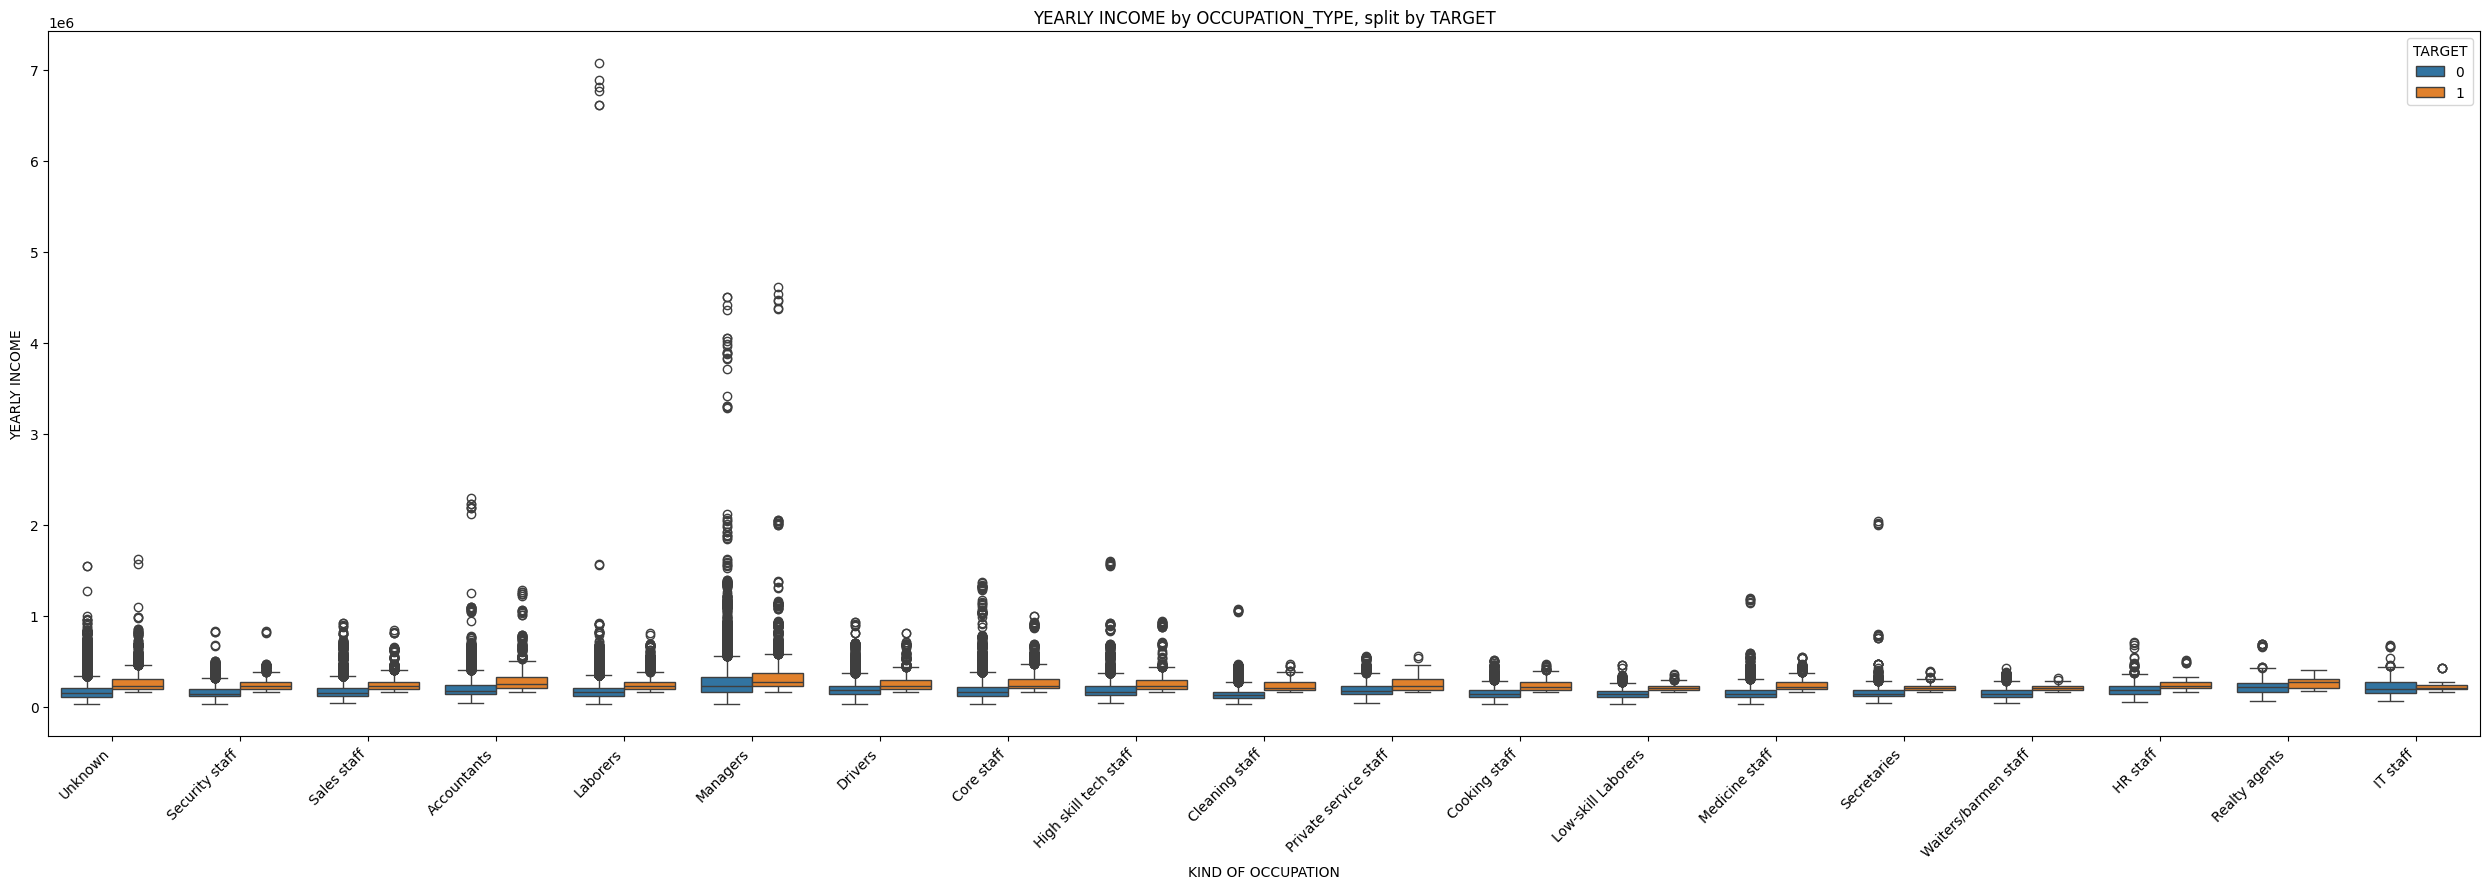

In [ ]:
# RELATIONSHIP BETWEEN "AMT_INCOME_TOTAL" AND "OCCUPATION_TYPE", CONDITIONED ON TARGET

plt.figure(figsize=(25, 9))

sns.boxplot(
    data=df_copy,
    x="OCCUPATION_TYPE",
    y="AMT_INCOME_TOTAL",
    hue="TARGET"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("KIND OF OCCUPATION")
plt.ylabel("YEARLY INCOME")
plt.title("YEARLY INCOME by OCCUPATION_TYPE, split by TARGET")
plt.legend(title="TARGET", loc="upper right")
plt.tight_layout()
plt.show()

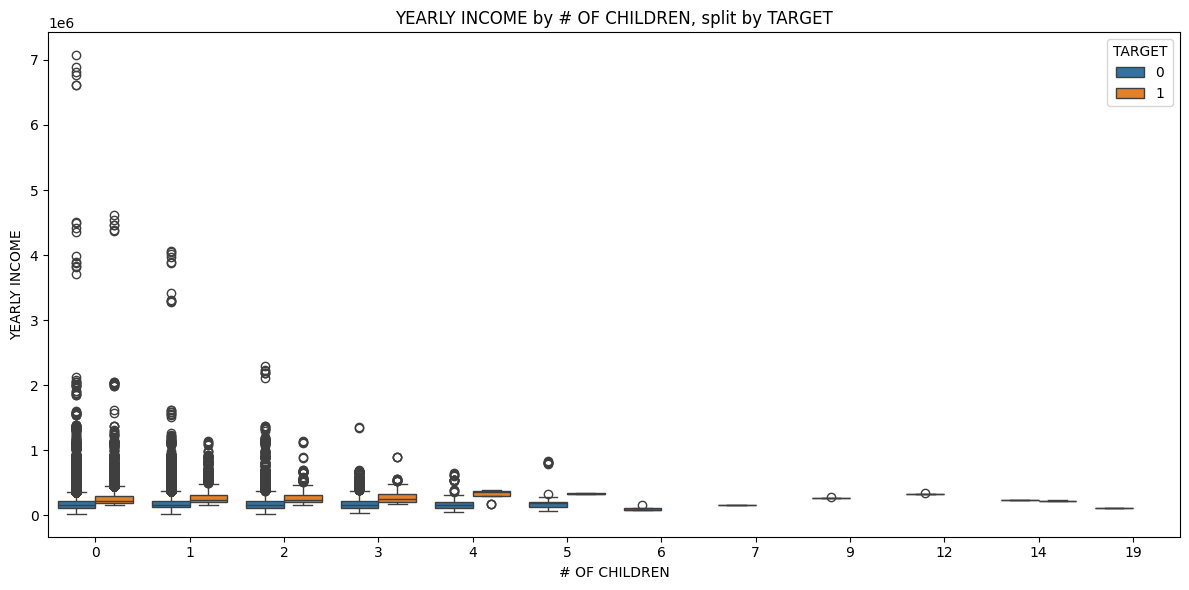

In [ ]:
# RELATIONSHIP BETWEEN "AMT_INCOME_TOTAL" AND "CNT_CHILDREN", CONDITIONED ON TARGET

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_copy,
    x="CNT_CHILDREN",
    y="AMT_INCOME_TOTAL",
    hue="TARGET"
)

plt.xlabel("# OF CHILDREN")
plt.ylabel("YEARLY INCOME")
plt.title("YEARLY INCOME by # OF CHILDREN, split by TARGET")
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()


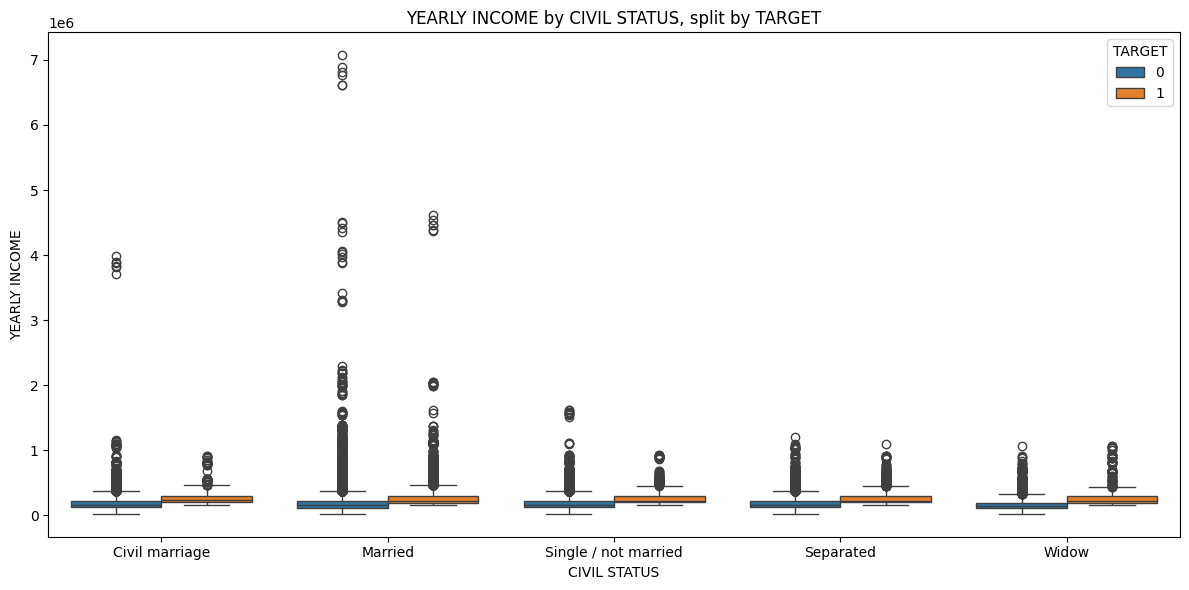

In [ ]:
# RELATIONSHIP BETWEEN "AMT_INCOME_TOTAL" AND "NAME_FAMILY_STATUS", CONDITIONED ON TARGET

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_copy,
    x="NAME_FAMILY_STATUS",
    y="AMT_INCOME_TOTAL",
    hue="TARGET"
)

plt.xlabel("CIVIL STATUS")
plt.ylabel("YEARLY INCOME")
plt.title("YEARLY INCOME by CIVIL STATUS, split by TARGET")
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

###Multivariate EDA: Key Findings

The bivariate analysis including annual income and the target showed a limited difference in medians and a strong overlap between the distributions.
The subsequent multivariate analyses, conditioned on occupation type, number of children, and marital status, confirm this evidence without revealing simple interactions or discriminatory thresholds.

This further highlights the importance of using a model such as the Random Forest, which can capture a relationship involving many variables in determining the target. There is no single variable with a decisive or primary contribution; instead, the contribution is distributed across multiple variables.

##Preprocessing

In [ ]:
df_copy.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,1,1,0,"424,380.57",Working,Higher education,Civil marriage,Rented apartment,"-11,778.00","-4,438.00",1,1,0,0,Unknown,2,0
1,5008805,M,1,1,0,"421,593.52",Working,Higher education,Civil marriage,Rented apartment,"-11,777.00","-4,459.00",1,1,0,0,Unknown,2,0
2,5008806,M,1,1,0,"110,958.51",Working,Secondary / secondary special,Married,House / apartment,"-21,471.00","-1,144.00",1,0,0,0,Security staff,2,0
3,5008808,F,0,1,0,"267,497.96",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-18,489.00","-3,122.00",1,0,1,1,Sales staff,1,1
4,5008809,F,0,1,0,"263,419.09",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,"-19,093.00","-3,070.00",1,0,1,1,Sales staff,1,1


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338426 non-null  int64  
 1   CODE_GENDER          338426 non-null  object 
 2   FLAG_OWN_CAR         338426 non-null  int64  
 3   FLAG_OWN_REALTY      338426 non-null  int64  
 4   CNT_CHILDREN         338426 non-null  int64  
 5   AMT_INCOME_TOTAL     338426 non-null  float64
 6   NAME_INCOME_TYPE     338426 non-null  object 
 7   NAME_EDUCATION_TYPE  338426 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  int64  
 13  FLAG_WORK_PHONE      338426 non-null  int64  
 14  FLAG_PHONE           338426 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
# SPLIT DATASET INTO TRAIN_SET AND TEST_SET

"""
Given the imbalance between the positive and negative classes,
I use the "stratify = y" argument so that each set has the same
target class proportions
"""
# DataFrame containing features only
X = df_copy.drop(columns=["TARGET", "ID"])

# Target Series
y = df_copy["TARGET"]

# Split the dataset to create TEST_SET and TRAIN_SET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify=y)


In [ ]:
# APPLY ONE-HOT ENCODING AND ORDINAL ENCODING

# Create a list of nominal categorical variables to which OHE will be applied
cat_nominal = ["CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"]


# Create a list containing the "NAME_EDUCATION_TYPE" variable to which the ordinal encoder will be applied
cat_ordinal = ["NAME_EDUCATION_TYPE"]

# Order of education levels contained in the "NAME_EDUCATION_TYPE" variable
edu_order = [["Lower secondary",
    "Secondary / secondary special",
    "Incomplete higher",
    "Higher education",
    "Academic degree"]]


# Create a list of quantitative variables (including binary 0/1 variables)
num_cols = ["AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED",
            "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
            "CNT_CHILDREN", "CNT_FAM_MEMBERS", "FLAG_MOBIL",
            "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"]


# Apply data transformations
transf = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_nominal),
        ("ord", OrdinalEncoder(categories=edu_order, handle_unknown="use_encoded_value",
                              unknown_value=-1), cat_ordinal),
        ("num", "passthrough", num_cols),],
    remainder="drop",
    verbose_feature_names_out=False
    )

X_train = transf.fit_transform(X_train)
X_test  = transf.transform(X_test)


##Define functions to visualize model structure and performance

In [ ]:
# Function to generate the report used to evaluate classification
def classifier_report(model, data):
  X, y = data
  y_pred = model.predict(X)
  report = classification_report(y, y_pred)
  print(report)
  print(confusion_matrix(y, y_pred))


# Function to visualize the Decision Tree
def tree_viz(tree, feature_names=None, class_names=None):
  dot_data = export_graphviz(tree, out_file=None,
                             feature_names=feature_names,
                             class_names=class_names,
                             filled=True,
                             rounded=True,
                             special_characters=True)

  graph = graphviz.Source(dot_data, filename="tree", format="png")
  graph.view()
  display(Image("tree.png"))


# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positive"], show_precision_recall=True):

  cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

  df_cm = pd.DataFrame(cm, index = labels,
                    columns = ["Predicted "+labels[0],"Predicted "+labels[1]])

  sns.heatmap(df_cm, annot=True, fmt='g')

  if show_precision_recall:

    # What percentage of positive classifications are actually positive?
    plt.text(0, -0.1, f"Precision: {(cm[1][1]/(cm[1][1]+cm[0][1])):.3f}")

    # What percentage of positive observations are classified as positive?
    plt.text(1, -0.1, f"Recall: {(cm[1][1]/(cm[1][1]+cm[1][0])):.3f}")

##Decision Tree Training

In order to be able to explain to a customer why they were or were not assigned reliable-customer status, a Decision Tree was developed, since this model is characterized by a high degree of interpretability and can therefore support an explanation of the reasons behind the resulting outcome.

Subsequently, for purely predictive purposes, a Random Forest will be developed to achieve better performance than a single Decision Tree.

In [ ]:
# LOOP TO SELECT THE BEST DECISION TREE

"""
I create a loop to identify the best depth for the model
between the values 4 and 5, setting class_weight = "balanced"
to compensate for the imbalance between the negative and positive classes.
"""

for depth in [4, 5]:
  print(f"Training a tree with maximum depth: {depth}")

  # Instantiate the class
  tree = DecisionTreeClassifier(max_depth = depth, class_weight = "balanced" )

  # Training on TRAIN_SET
  tree.fit(X_train, y_train)

  # Print results
  print(f"Accuracy: Train={tree.score(X_train, y_train):.3f} | Test={tree.score(X_test, y_test):.3f}")

  print("Classifier Report Train Set")

  classifier_report(tree, (X_train, y_train))

  print(f"Classifier Report Test Set")

  classifier_report(tree, (X_test, y_test))

  print("-"*50)

Training a tree with maximum depth: 4
Accuracy: Train=0.947 | Test=0.948
Classifier Report Train Set
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    216093
           1       0.63      0.99      0.77     20805

    accuracy                           0.95    236898
   macro avg       0.81      0.97      0.87    236898
weighted avg       0.97      0.95      0.95    236898

[[203792  12301]
 [   180  20625]]
Classifier Report Test Set
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     92611
           1       0.63      0.99      0.77      8917

    accuracy                           0.95    101528
   macro avg       0.81      0.97      0.87    101528
weighted avg       0.97      0.95      0.95    101528

[[87424  5187]
 [   60  8857]]
--------------------------------------------------
Training a tree with maximum depth: 5
Accuracy: Train=0.948 | Test=0.949
Classifier Report Train Set


The results of the models with the two different depths show that, all other parameters being equal, a value of 4 is the threshold beyond which the model's discriminatory power does not show any improvement.

Starting from a depth of 4, different values for `min_samples_leaf` (100, 200, 500, 1000) were explored but are not reported here, because this additional structural constraint did not provide benefits. This is probably because, with a depth of 4 and a dataset of more than 300k observations, the model's leaves already contain a number of observations well above the 1000 set in the parameter.

In [ ]:
# TRAIN THE SELECTED MODEL (MAX_DEPTH = 4)

# Instantiate the class
tree = DecisionTreeClassifier(max_depth = 4, class_weight = "balanced" )

# Training on TRAIN_SET
tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4)

In [ ]:
# MAKE A PREDICTION ON THE TEST SET

y_pred_test = tree.predict(X_test)

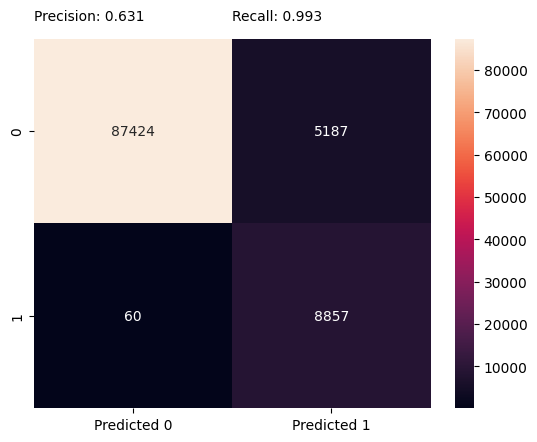

In [ ]:
# CONFUSION MATRIX VISUALIZATION

plot_confusion_matrix(y_test, y_pred_test, ["0", "1"])

The results show a model capable of identifying almost all reliable customers, at the cost of precision (approximately 0.63) because of a substantial number of False Positives.

The model does not overfits, because performance on the TRAIN and TEST sets is practically identical.

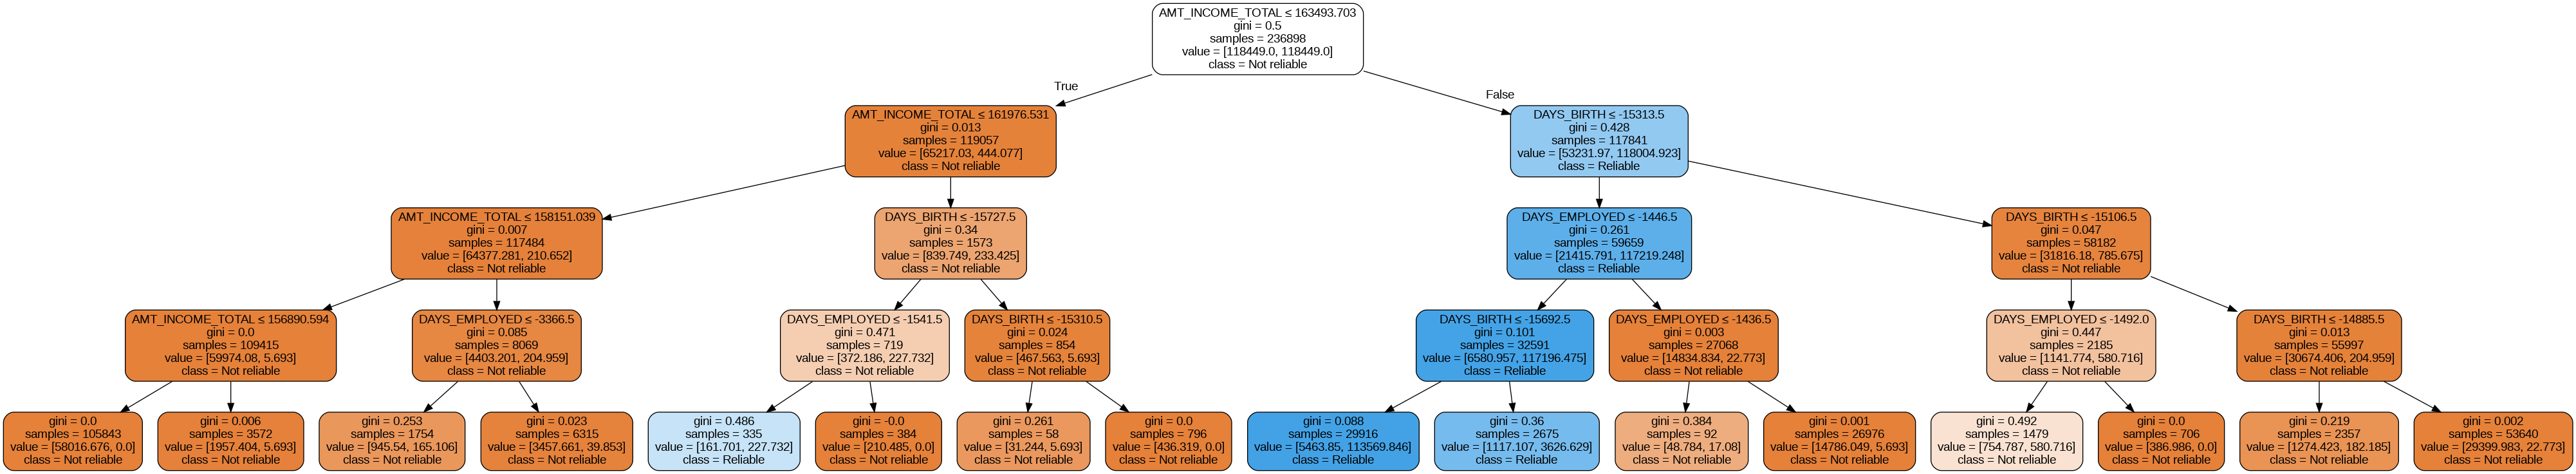

In [ ]:
# VISUALIZE THE TREE

# Retrieve the list of features
feature_names = transf.get_feature_names_out()

# Plot the Decision Tree
tree_viz(tree, feature_names=feature_names,
         class_names=["Not reliable", "Reliable"])

The tree shows the rationale underlying customer classification. Considering the blue branch that starts from the False outcome of the parent node, the tree tells us that if the subject, in order:
- has an income greater than approximately $163k;
- is older than approximately 42–43 years;
- has more than approximately 4 years of work experience

then the customer is reliable.

If a customer asked why someone with an income below that threshold, younger than that age, and with less work experience is classified as not reliable, we could not answer that an income below that threshold causes payment default. What we should explain is that, statistically, customers with those characteristics proved to be punctual in their payments only after receiving credit, and therefore the classification is based on what has statistically emerged over time: namely, that individuals with certain characteristics turned out to be reliable ex post, without addressing what actually causes default. Causality is not investigated; instead, the ex-post behaviour of each subject is observed and the characteristics of each individual are collected.

The classification is based on a snapshot of the characteristics of past customers in both categories, without investigating causal relationships between those characteristics and whether or not payments were made.

Therefore, it is as if the model were answering the question: given this person with these characteristics, how can we classify them based on what happened in the past (ex-post classification as 0 or 1) with people who had similar characteristics?

##Random Forest Training

In [ ]:
# LOOP TO SELECT THE BEST RANDOM FOREST

# Loop to select the best-performing Forest
for n_tree in [50, 100, 500, 1000]:

  print(f"Training a forest with {n_tree} trees.")

  # Instantiate the class
  forest = RandomForestClassifier(n_estimators=n_tree,
                                  n_jobs = -1,
                                  class_weight = "balanced")

  # Training on TRAIN_SET
  forest.fit(X_train, y_train)

  # Predictions on TEST_SET
  y_pred_test = forest.predict(X_test)

  # Print results
  print(f"Accuracy: Train = {forest.score(X_train, y_train):.3f} | Test = {forest.score(X_test, y_test):.3f}\n"
        f"Recall: Test = {recall_score(y_test, y_pred_test, pos_label=1):.3f}\n"
        f"F1: Test = {f1_score(y_test, y_pred_test, pos_label=1):.3f}")
  print("-"*50)

Training a forest with 50 trees.
Accuracy: Train = 1.000 | Test = 0.948
Recall: Test = 0.726
F1: Test = 0.709
--------------------------------------------------
Training a forest with 100 trees.
Accuracy: Train = 1.000 | Test = 0.949
Recall: Test = 0.737
F1: Test = 0.715
--------------------------------------------------
Training a forest with 500 trees.
Accuracy: Train = 1.000 | Test = 0.949
Recall: Test = 0.745
F1: Test = 0.719
--------------------------------------------------
Training a forest with 1000 trees.
Accuracy: Train = 1.000 | Test = 0.949
Recall: Test = 0.746
F1: Test = 0.719
--------------------------------------------------


In [ ]:
# TRAIN THE SELECTED FOREST (TREES = 500)

# Instantiate the class
forest = RandomForestClassifier(n_estimators = 500,
                                  class_weight = "balanced")
# Training on TRAIN_SET
forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500)

In [ ]:
# MAKE A PREDICTION ON THE TEST SET

y_pred_test = forest.predict(X_test)

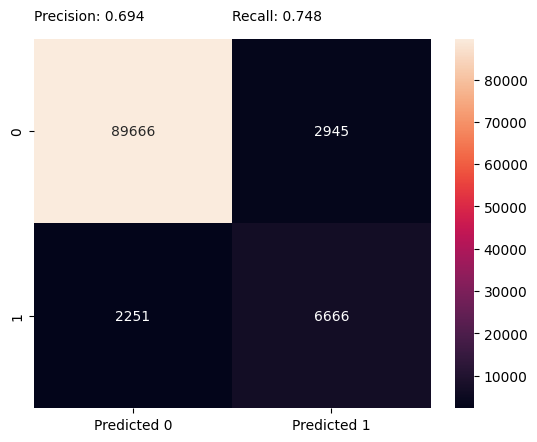

In [ ]:
# CONFUSION MATRIX VISUALIZATION

plot_confusion_matrix(y_test, y_pred_test, ["0", "1"])

The properly balanced Decision Tree shows a very high ability to identify reliable customers, at the cost of a substantial number of false positives.

The Random Forest, while improving model robustness, shows a reduction in recall for the positive class due to the averaging effect across heterogeneous trees.

Considering the characteristics of the activity the model is designed to support, the results could be considered satisfactory: compared with the Decision Tree, the model identifies about 25% fewer customers who could be considered reliable given their characteristics, but it reduces the number of false positives by 43%.

Further refinement of the model obviously depends on the bank's objective: whether to maximize the number of reliable customers in order to increase business volume, or to reduce false positives in order to avoid complications related to the management of customers who default.